Undersampling + Sliding Window

In [1]:
import pandas as pd

train_df = pd.read_csv(r"train_final.csv")
valid_df = pd.read_csv(r"val_final.csv")
test_df = pd.read_csv(r"test_final.csv")


def prepare_time_order(df):
    df = df.copy()
    df["datetime_obj"] = pd.to_datetime(df["timestamp"], format="ISO8601", utc=True)
    df["timestamp_num"] = df["datetime_obj"].astype("int64") / 1e9
    df = df.sort_values(by="timestamp_num").reset_index(drop=True)
    return df, df["timestamp_num"].copy()


train_df, train_timestamps = prepare_time_order(train_df)
valid_df, valid_timestamps = prepare_time_order(valid_df)
test_df, test_timestamps = prepare_time_order(test_df)

cols_to_drop = [
    "timestamp",
    "datetime_obj",
    "timestamp_num",
    "network_ips_dst",
    "network_ips_src",
    "network_ports_dst",
    "network_ports_src",
]

train_df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
valid_df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
test_df.drop(columns=cols_to_drop, inplace=True, errors="ignore")


In [2]:
import torch
from torch.utils.data import Dataset
import numpy as np

class DynamicUndersampledSlidingWindowDataset(Dataset):
    def __init__(self, df, time_steps, max_samples_per_class=20000, 
                 step=5, resample_each_epoch=False, rare_classes=None):
        

        if rare_classes is None:
            rare_classes = [9, 10]
            
        feat_cols = [col for col in df.columns if col != 'label']
        self.X = torch.as_tensor(df[feat_cols].to_numpy(dtype=np.float32))
        self.y = torch.as_tensor(df['label'].to_numpy(dtype=np.int64))
        
        self.time_steps = time_steps
        self.step = step
        self.max_samples_per_class = max_samples_per_class
        self.resample_each_epoch = resample_each_epoch
        
        # Tạo 2 mảng index: 1 cái step=1 (bảo toàn), 1 cái có step (băm mỏng)
        all_indices_step1 = np.arange(0, len(self.X) - self.time_steps + 1, 1)
        window_labels_step1 = self.y[all_indices_step1 + self.time_steps - 1].numpy()
        
        all_indices_stepped = np.arange(0, len(self.X) - self.time_steps + 1, self.step)
        window_labels_stepped = self.y[all_indices_stepped + self.time_steps - 1].numpy()
        
        self.class_indices = {}
        for c in np.unique(window_labels_step1):
            if c in rare_classes:
                # Bảo toàn 100% dữ liệu cho class hiếm
                self.class_indices[c] = all_indices_step1[window_labels_step1 == c]
            else:
                # Băm mỏng theo step đối với các class đa số
                self.class_indices[c] = all_indices_stepped[window_labels_stepped == c]
            
            print(f"Class {c}: Có sẵn {len(self.class_indices[c])} cửa sổ trong Pool")
            
        self._resample()
    
    def _resample(self):
        self.valid_indices = []
        for c, c_indices in self.class_indices.items():
            count = len(c_indices)
            
            # NẾU LÀ TẬP TRAIN (có bật resample_each_epoch)
            if self.resample_each_epoch:
                if count > self.max_samples_per_class:
                    # Dư thì băm đi (Undersampling)
                    sampled = np.random.choice(c_indices, self.max_samples_per_class, replace=False)
                else:
                    # Thiếu thì nhân bản (Oversampling)
                    sampled = np.random.choice(c_indices, self.max_samples_per_class, replace=True)
                    
            # NẾU LÀ TẬP VAL/TEST (Giữ nguyên gốc 100%, không thêm không bớt)
            else:
                sampled = c_indices
                
            self.valid_indices.extend(sampled)
            
        np.random.shuffle(self.valid_indices)
        self.valid_indices = np.array(self.valid_indices)
    def on_epoch_start(self):
        if self.resample_each_epoch:
            self._resample()

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        window_X = self.X[actual_idx : actual_idx + self.time_steps]
        label_y = self.y[actual_idx + self.time_steps - 1]
        return window_X, label_y

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# hàm tính focal loss (hiện đang không dùng Focal Loss)
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


In [4]:
import torch
import torch.nn as nn

NUM_FEATURES = len([col for col in train_df.columns if col != 'label'])
NUM_CLASSES = train_df['label'].nunique()

# tính attention cho output của BiLSTM và tạo vector ngữ cảnh (context vector)
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_outputs):
        scores = self.attention(lstm_outputs)
        weights = torch.softmax(scores, dim=1)
        context_vector = torch.sum(weights * lstm_outputs, dim=1)
        return context_vector, weights

# SE Block: từ đầu ra là các channel từ CNN, kênh nào chiếm tín hiệu rõ ràng thì trọng số là 1, kênh nào bị nhiễu or sai lệch thì trọng số = 0
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super(SEBlock1D, self).__init__()
        # từ các channel của CNN, tính average pooling theo chiều thời gian
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        
        # tính điểm dựa trên 1 mạng neural channel => channel/8 => channel và đi qua hàm sigmoid để tạo thang điểm 0-1 cho từng kênh
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    # b,c: batch size, số kênh
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c) # tính toán điểm trung bình của các channel theo chiều thời gian
        y = self.fc(y).view(b, c, 1)    # tính ra thang điểm 0-1 cho từng kênh
        return x * y.expand_as(x)       # nhân điểm số này với các channel để khuếch đại kênh chuẩn và bóp nghẹt kênh bị nhiễm Drift

# residual block: CNN tích hợp SE Block và shortcut connection 
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super(ResidualBlock1D, self).__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding) # đi qua lớp convoluation đầu tiên
        self.gn1 = nn.GroupNorm(num_groups=8, num_channels=out_channels) # group norm: chuẩn hóa độc lập theo từng nhóm kênh
        self.relu = nn.ReLU() # hàm kích hoạt ReLU
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding) # đi qua lớp convolution thứ hai
        self.gn2 = nn.GroupNorm(num_groups=8, num_channels=out_channels) # chuẩn hóa sau lớp convolution thứ hai
        self.dropout = nn.Dropout1d(0.2)
        
        # SE Block: chấm điểm đầu ra cho các channel của CNN
        self.se = SEBlock1D(out_channels)
        
        # shortcut connection
        self.shortcut = nn.Sequential()
        if in_channels != out_channels: # nếu số kênh đầu vào khác số kênh đầu ra thì shortcut phải dùng convolution để điều chỉnh số kênh
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.GroupNorm(num_groups=8, num_channels=out_channels)
            )
            
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.conv1(x)
        out = self.gn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.gn2(out)
        out = self.se(out)
        out += residual  
        out = self.relu(out)
        return out


# model CNN-BiLSTM hoàn chỉnh
class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, num_features, num_classes, time_steps, hidden_size=128):
        super(CNN_BiLSTM_Attention, self).__init__()
        
        # 2 khối Residual Block
        self.res1 = ResidualBlock1D(num_features, 64)
        self.res2 = ResidualBlock1D(64, 128)
        
        # giảm chiều dài chuỗi đi một nửa
        self.pool = nn.MaxPool1d(kernel_size=2) 
        
        # cho BiLSTM nhận đầu vào là 128 channel, tạo ra output có chiều dài hiden_size*2
        self.bilstm = nn.LSTM(input_size=128, hidden_size=hidden_size, 
                              batch_first=True, bidirectional=True)
        
        # chuẩn hóa layer norm theo từng time-step
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        # tính attention score cho output của BiLSTM và tạo vector ngữ cảnh (context vector)
        self.attention = Attention(hidden_size * 2)
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(hidden_size * 2, 64)
        # Tăng cường ổn định ở bộ phân loại cuối
        self.fc_ln = nn.LayerNorm(64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # x ban đầu: (Batch, SeqLen, Features)
        x = x.permute(0, 2, 1) # chuyển thành (Batch, Features, SeqLen) để phù hợp với đầu vào của CNN
        
        # đi qua các khối Residual CNN + SE Block
        x = self.res1(x)
        x = self.res2(x)
        
        x = self.pool(x)
        
        # chuyển lại thành (batch, seq_len, features) để phù hợp với đầu vào của BiLSTM
        x = x.permute(0, 2, 1)
        
        out, _ = self.bilstm(x)
        
        # chuẩn hóa layer norm theo từng time-step + tính attention score để tạo vector ngữ cảnh
        out = self.layer_norm(out)
        context_vector, attn_weights = self.attention(out)
        
        # đi qua 2 lớp fully connected với dropout và layer norm để tăng cường ổn định
        out = self.dropout(context_vector)
        out = self.fc1(out) 
        out = self.fc_ln(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {DEVICE}")

Đang sử dụng thiết bị: cuda


Thử nghiệm nhiều giá trị k


In [5]:
import copy
import random

import pandas as pd
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from torch.utils.data import DataLoader
from tqdm import tqdm


# Giữ nguyên config train cũ, chỉ thay đổi k = TIME_STEPS.
K_VALUES = [2, 4, 6, 8, 10, 12, 14, 16]
MAX_SAMPLES = 20000
BATCH_SIZE = 256
TEST_STEP_SIZE = 1
TRAIN_STEP_SIZE = 1
EPOCHS = 60
EARLY_STOP_PATIENCE = 20
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 1e-3
GLOBAL_SEED = 50


def set_seed(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def mean_window_delta_t_under_1h(timestamp_nums, valid_indices, k):
    start_times = timestamp_nums.iloc[valid_indices].reset_index(drop=True)
    end_times = timestamp_nums.iloc[valid_indices + k - 1].reset_index(drop=True)
    delta_seconds = (end_times - start_times).dropna()
    delta_seconds = delta_seconds[(delta_seconds >= 0) & (delta_seconds < 3600)]

    if delta_seconds.empty:
        return {
            "mean_seconds": np.nan,
            "mean_minutes": np.nan,
            "window_count_under_1h": 0,
        }

    return {
        "mean_seconds": delta_seconds.mean(),
        "mean_minutes": delta_seconds.mean() / 60,
        "window_count_under_1h": len(delta_seconds),
    }


def print_delta_t_summary(k, split_name, stats):
    print(
        f"k={k} | {split_name} mean delta t (<1h): "
        f"{stats['mean_minutes']:.4f} phut "
        f"({stats['mean_seconds']:.2f} giay), "
        f"so cua so hop le: {stats['window_count_under_1h']}"
    )


def train_and_evaluate_for_k(k):
    set_seed(GLOBAL_SEED)

    print("=" * 90)
    print(f"BAT DAU THU NGHIEM VOI k = {k}")
    print("=" * 90)

    train_dataset = DynamicUndersampledSlidingWindowDataset(
        train_df,
        k,
        max_samples_per_class=MAX_SAMPLES,
        step=TRAIN_STEP_SIZE,
    )
    val_dataset = DynamicUndersampledSlidingWindowDataset(
        valid_df,
        k,
        max_samples_per_class=10_000_000,
        step=TEST_STEP_SIZE,
    )
    test_dataset = DynamicUndersampledSlidingWindowDataset(
        test_df,
        k,
        max_samples_per_class=10_000_000,
        step=TEST_STEP_SIZE,
    )

    train_delta_t = mean_window_delta_t_under_1h(train_timestamps, train_dataset.valid_indices, k)
    val_delta_t = mean_window_delta_t_under_1h(valid_timestamps, val_dataset.valid_indices, k)
    test_delta_t = mean_window_delta_t_under_1h(test_timestamps, test_dataset.valid_indices, k)

    print_delta_t_summary(k, "Train", train_delta_t)
    print_delta_t_summary(k, "Val", val_delta_t)
    print_delta_t_summary(k, "Test", test_delta_t)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = CNN_BiLSTM_Attention(
        num_features=NUM_FEATURES,
        num_classes=NUM_CLASSES,
        time_steps=k,
    ).to(DEVICE)

    # Giữ nguyên loss/optimizer/scheduler như cell train cũ.
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        verbose=True,
    )

    best_val_f1 = 0.0
    best_epoch = 0
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        total_train = 0
        all_train_preds = []
        all_train_targets = []

        loop = tqdm(train_loader, desc=f"k={k} | Epoch {epoch + 1}/{EPOCHS} [Train]", leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_targets.extend(labels.cpu().numpy())
            loop.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / total_train
        train_macro_f1 = f1_score(all_train_targets, all_train_preds, average="macro", zero_division=0)

        model.eval()
        val_loss = 0.0
        total_val = 0
        all_val_preds = []
        all_val_targets = []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"k={k} | Epoch {epoch + 1}/{EPOCHS} [Validation]", leave=False):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_targets.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / total_val
        val_macro_f1 = f1_score(all_val_targets, all_val_preds, average="macro", zero_division=0)

        print(
            f"k={k} | Epoch [{epoch + 1}/{EPOCHS}] - "
            f"Train Loss: {avg_train_loss:.4f}, Train Macro F1: {train_macro_f1:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}, Val Macro F1: {val_macro_f1:.4f}"
        )

        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP_PATIENCE:
                print(f"\n[Early Stopping] k={k}: Val Macro F1 khong cai thien sau {EARLY_STOP_PATIENCE} epochs.")
                break

    model.load_state_dict(best_model_state)
    model.eval()

    all_test_preds = []
    all_test_targets = []
    all_test_probas = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"k={k} | [Final Test]", leave=False):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probas = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)

            all_test_preds.extend(predicted.cpu().numpy())
            all_test_targets.extend(labels.cpu().numpy())
            all_test_probas.extend(probas.cpu().numpy())

    all_test_targets = np.array(all_test_targets)
    all_test_preds = np.array(all_test_preds)
    all_test_probas = np.array(all_test_probas)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_test_targets,
        all_test_preds,
        average="macro",
        zero_division=0,
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        all_test_targets,
        all_test_preds,
        average="weighted",
        zero_division=0,
    )

    try:
        auc_roc_macro_ovr = roc_auc_score(
            all_test_targets,
            all_test_probas,
            multi_class="ovr",
            average="macro",
            labels=np.arange(NUM_CLASSES),
        )
    except ValueError as exc:
        auc_roc_macro_ovr = np.nan
        print(f"[Canh bao] k={k}: khong tinh duoc AUC-ROC ({exc})")

    print(f"\n--- BAO CAO PHAN LOAI TREN TAP TEST | k={k} | best_epoch={best_epoch} ---")
    print(classification_report(all_test_targets, all_test_preds, zero_division=0, digits=4))
    print(f"AUC-ROC Macro OVR: {auc_roc_macro_ovr:.4f}")

    return {
        "k": k,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_f1,
        "test_precision_macro": macro_precision,
        "test_recall_macro": macro_recall,
        "test_f1_macro": macro_f1,
        "test_precision_weighted": weighted_precision,
        "test_recall_weighted": weighted_recall,
        "test_f1_weighted": weighted_f1,
        "test_auc_roc_macro_ovr": auc_roc_macro_ovr,
        "train_mean_delta_t_seconds_under_1h": train_delta_t["mean_seconds"],
        "train_mean_delta_t_minutes_under_1h": train_delta_t["mean_minutes"],
        "train_window_count_delta_t_under_1h": train_delta_t["window_count_under_1h"],
        "val_mean_delta_t_seconds_under_1h": val_delta_t["mean_seconds"],
        "val_mean_delta_t_minutes_under_1h": val_delta_t["mean_minutes"],
        "val_window_count_delta_t_under_1h": val_delta_t["window_count_under_1h"],
        "test_mean_delta_t_seconds_under_1h": test_delta_t["mean_seconds"],
        "test_mean_delta_t_minutes_under_1h": test_delta_t["mean_minutes"],
        "test_window_count_delta_t_under_1h": test_delta_t["window_count_under_1h"],
    }


experiment_results = []
for k in K_VALUES:
    result = train_and_evaluate_for_k(k)
    experiment_results.append(result)

results_df = pd.DataFrame(experiment_results)
print("\n=== TONG HOP KET QUA THEO k ===")
display(results_df)


BAT DAU THU NGHIEM VOI k = 2
Class 0: Có sẵn 95760 cửa sổ trong Pool
Class 1: Có sẵn 1307 cửa sổ trong Pool
Class 2: Có sẵn 12639 cửa sổ trong Pool
Class 3: Có sẵn 12894 cửa sổ trong Pool
Class 4: Có sẵn 5278 cửa sổ trong Pool
Class 5: Có sẵn 5643 cửa sổ trong Pool
Class 6: Có sẵn 23552 cửa sổ trong Pool
Class 7: Có sẵn 1957 cửa sổ trong Pool
Class 0: Có sẵn 20520 cửa sổ trong Pool
Class 1: Có sẵn 280 cửa sổ trong Pool
Class 2: Có sẵn 2708 cửa sổ trong Pool
Class 3: Có sẵn 2763 cửa sổ trong Pool
Class 4: Có sẵn 1131 cửa sổ trong Pool
Class 5: Có sẵn 1209 cửa sổ trong Pool
Class 6: Có sẵn 5046 cửa sổ trong Pool
Class 7: Có sẵn 419 cửa sổ trong Pool
Class 0: Có sẵn 20520 cửa sổ trong Pool
Class 1: Có sẵn 281 cửa sổ trong Pool
Class 2: Có sẵn 2709 cửa sổ trong Pool
Class 3: Có sẵn 2763 cửa sổ trong Pool
Class 4: Có sẵn 1132 cửa sổ trong Pool
Class 5: Có sẵn 1210 cửa sổ trong Pool
Class 6: Có sẵn 5047 cửa sổ trong Pool
Class 7: Có sẵn 420 cửa sổ trong Pool
k=2 | Train mean delta t (<1h): 0

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


k=2 | Epoch [1/60] - Train Loss: 0.8361, Train Macro F1: 0.7064 | Val Loss: 0.7026, Val Macro F1: 0.7351


k=2 | Epoch [2/60] - Train Loss: 0.6891, Train Macro F1: 0.8720 | Val Loss: 0.7159, Val Macro F1: 0.7352


k=2 | Epoch [3/60] - Train Loss: 0.6705, Train Macro F1: 0.8936 | Val Loss: 0.7030, Val Macro F1: 0.7578


...

k=16 | Epoch [21/60] - Train Loss: 0.5015, Train Macro F1: 0.9919 | Val Loss: 0.8542, Val Macro F1: 0.7160


k=16 | Epoch [22/60] - Train Loss: 0.5016, Train Macro F1: 0.9921 | Val Loss: 0.8576, Val Macro F1: 0.6952


k=16 | Epoch [23/60] - Train Loss: 0.5014, Train Macro F1: 0.9927 | Val Loss: 0.8592, Val Macro F1: 0.7268

[Early Stopping] k=16: Val Macro F1 khong cai thien sau 20 epochs.



--- BAO CAO PHAN LOAI TREN TAP TEST | k=16 | best_epoch=3 ---
              precision    recall  f1-score   support

           0     0.9873    0.9992    0.9932     20520
           1     0.0693    0.0498    0.0580       281
           2     0.6467    0.3629    0.4649      2709
           3     0.5667    0.6826    0.6193      2763
           4     0.9956    0.9973    0.9965      1132
           5     0.9865    0.3017    0.4620      1210
           6     0.8248    1.0000    0.9040      5033
           7     0.6006    0.9238    0.7280       420

    accuracy                         0.8894     34068
   macro avg     0.7097    0.6647    0.6532     34068
weighted avg     0.8900    0.8894    0.8780     34068

AUC-ROC Macro OVR: 0.9782

=== TONG HOP KET QUA THEO k ===


,k,best_epoch,best_val_macro_f1,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_auc_roc_macro_ovr,train_mean_delta_t_seconds_under_1h,train_mean_delta_t_minutes_under_1h,train_window_count_delta_t_under_1h,val_mean_delta_t_seconds_under_1h,val_mean_delta_t_minutes_under_1h,val_window_count_delta_t_under_1h,test_mean_delta_t_seconds_under_1h,test_mean_delta_t_minutes_under_1h,test_window_count_delta_t_under_1h
0,2,3,0.757817,0.752448,0.640098,0.651972,0.882132,0.876680,0.858741,0.958073,0.819732,0.013662,159010,1.082179,0.018036,34064,1.061212,0.017687,34068
1,4,2,0.789259,0.755914,0.657499,0.676899,0.893812,0.895511,0.882848,0.971446,2.459168,0.040986,158968,3.247219,0.054120,34038,3.184218,0.053070,34038
2,6,2,0.767722,0.764817,0.659920,0.660391,0.908840,0.892570,0.875199,0.969218,4.098585,0.068310,158926,5.413133,0.090219,34012,5.303610,0.088393,34008
3,8,3,0.815351,0.828767,0.744468,0.753361,0.909249,0.904390,0.893131,0.975457,5.738008,0.095633,158884,7.571327,0.126189,33986,7.417602,0.123627,33978
4,10,1,0.780353,0.765271,0.702341,0.708999,0.910209,0.908669,0.901690,0.970136,7.377434,0.122957,158842,9.730402,0.162173,33960,9.530502,0.158842,33948
5,12,5,0.778109,0.688306,0.650104,0.642260,0.880747,0.881692,0.872457,0.966835,9.016866,0.150281,158800,11.882551,0.198043,33934,11.644092,0.194068,33918
6,14,2,0.788853,0.763629,0.712330,0.700297,0.901521,0.893367,0.883355,0.977204,10.656303,0.177605,158758,14.035557,0.233926,33908,13.758408,0.229307,33888
7,16,3,0.786034,0.709696,0.664658,0.653224,0.890030,0.889427,0.877955,0.978235,12.295745,0.204929,158716,16.189438,0.269824,33882,15.873446,0.264557,33858


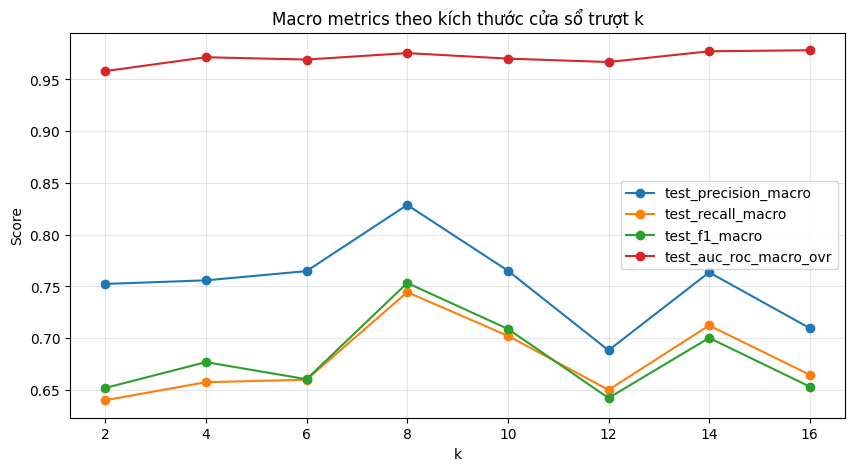

In [9]:
import matplotlib.pyplot as plt

plot_df = results_df.sort_values("k")

metrics = [
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro",
    "test_auc_roc_macro_ovr",
]

plt.figure(figsize=(10, 5))
for metric in metrics:
    plt.plot(plot_df["k"], plot_df[metric], marker="o", label=metric)

plt.xlabel("k")
plt.ylabel("Score")
plt.title("Macro metrics theo kích thước cửa sổ trượt k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

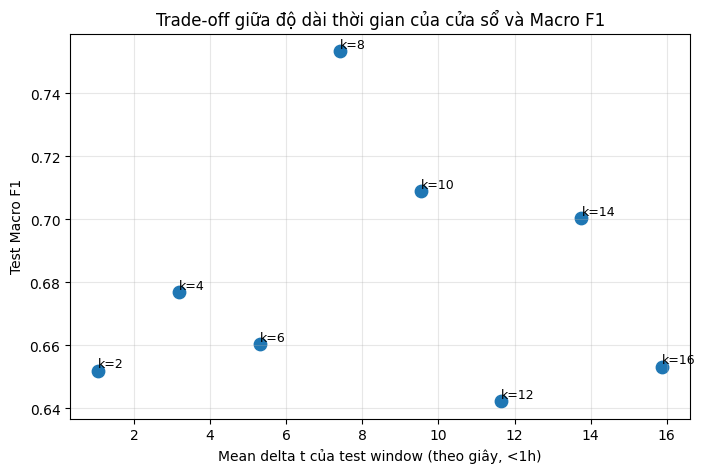

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(
    plot_df["test_mean_delta_t_seconds_under_1h"],
    plot_df["test_f1_macro"],
    s=80,
)

for _, row in plot_df.iterrows():
    plt.text(
        row["test_mean_delta_t_seconds_under_1h"],
        row["test_f1_macro"],
        f"k={int(row['k'])}",
        fontsize=9,
        ha="left",
        va="bottom",
    )

plt.xlabel("Mean delta t của test window (theo giây, <1h)")
plt.ylabel("Test Macro F1")
plt.title("Trade-off giữa độ dài thời gian của cửa sổ và Macro F1")
plt.grid(True, alpha=0.3)
plt.show()